# First experiments 

## Case study - business problem

The aim is to build a model that predicts default risk at the time of loan application for Estonia (EE). An 'application time' model should consider information available only at or before the application submission date/time 'LoanApplicationStartedDate' (I consider the 'LoanDate' is also created at that time). I exclude from the analysis variables that: have no modelling value (e.g. 'LoanID'), are completely empty (e.g. 'City'), contain model-related features (e.g. 'Rating', 'Rating_Vx', 'ProbabilityOfDefault', 'EL_VX'), include future information ('Bidxxx'), imply default has occured ('LGD'), contain external scores not applicable for EE. I exclude the variable 'Interest' assuming it is created by risk-based pricing.   

As a target variable I choose the default of a borrower over a 12-month horizon ('default12'). I construct it using the 'LoanDate' and the 'DefaultDate'. The default12 is suitable for an application-time model, that uses input available at the time of application in order to accept or reject a loan, it is aligned with standard credit risk practice, and it allows expected loss and profit calculations, which require the predicted probability of default. I check the number of observations and the default rate per year. I choose **2016-2020** as a time-period for the analysis, with **2016-2018** as a training period and **2019-2020** as a testing period. The analysis period counts higher number of loans as compared to the earlier years consisting a quite stable period. Furthermore, the default rate decreased from **19.3%** in the training period to **14.8%** in the testing period, indicating a moderate shift in portfolio risk. This reflects realistic portfolio dynamics and supports the use of a time-based split to evaluate model performance and generalisation **(Answer 1)**.

Two modelling techniques are used to predict the probability of default in this assignment: Logistic Regression (model LR), and Gradient Boosting (model GB). Logistic regression is a widely used benchmark model in credit risk modelling. It provides high interpretability, allows clear understanding of how each variable influences the probability of default, and generally produces stable results. Gradient Boosting is a tree-based ensemble method capable of capturing non-linear relationships and complex interactions between variables that linear models may fail to detect. By comparing Gradient Boosting with Logistic Regression, we can evaluate whether the additional modelling complexity translates into meaningfully improved predictive power **(Answer 3)**. 

As a first approach I use all available features (after excluding the features mentioned above which leaves 39 features), replacing '-1's, handling missing values (substituting missing values with the mean and most common value from the training set for nominal and categorical variables respectively), encoding categorical variables (39 features give 84 columns), and scaling nominal variables for Logistic Regression. Both models are trained over the same training period and using the same features. Performance metrics are provided below (Table: Performance).

| 	         | LR	    | GB       | LR	      | GB        |
| -----------| ---------| ---------| ---------| ----------
| Nr of features | 39	  | 39       | 20	    | 20      |
| TRAIN AUC	 | 0,668 |	0,684 |	0,653 |	0,683
| TRAIN Gini | 0,335 |	0,369 |	0,306 |	0,367
| TEST AUC	 | 0,671 |	0,670 |	0,652 |	0,669
| TEST Gini	 | 0,341 |	0,340 |	0,304 |	0,337
| ΔGini	     | 0,006 |	0,029 |	0,003 |	0,029
<figcaption>Table: Performance</figcaption>

The AUC values of both models are above 0,5 therefore both models discriminate good/bad borrowers relatively good and the Gini values are positive therefore the higher the model score the higher the number of predicted defaults is. For a consumer loan business the above AUC, Gini values are typical and acceptable for model performance. In addition the ΔGinis (difference between train Gini and test Gini) are low (<0,05) indicating generalization (no overfitting). In this configuration (using all 39 features), both models show similar performance (0,34 in test set). The fact that the GB model does not significantly outperform LR in the test set, suggests that the predictive signal in the dataset is mostly linear, therefore there is no predictive gain with modelling complexity **(Answer 4)**.

Before deciding on the model of choice, I use a simplified approach to decrease the number of features (from 39 to 20). I rank the variables based on importance coming from the GB model, and take the most important variables. I re-train both models on that reduced set of variables and I re-assess model performance. On that set LR starts to slightly underperform, while GB keeps performance stable. Despite the slightly higher performance from GB, the **'LR with 20 features'** is selected as the model to further work on, due to:
1. its interpretability (easier to calculate variable contribution than in GB), 
1. its stability (smaller ΔGinis in LR than in GB means better generalization on unseen data),
1. its ease for monitoring against the LR with 39 features, and
1. its widespread use **(Answer 5)**.

Based on the chosen model (LR-20) the two variables of highest importance are 'NewCreditCustomer' and 'CreditScoreEeMini'. They have positive-strong and negative-strong relationship with the target variable in the model respectively (coefficients +0.239766 and -0.236024), and they are both statistically significant, since univariate logistic regression models with the target variable yield p-values practically zero **(Answer 6)**. 

Next, I briefly touch two topics directly relevant with business use of the chosen model: Based on the chosen model, I firstly check how well the predicted PDs align with the observed DRs (Table: Calibration), and secondly I calculate acceptance and default rates on different PD thresholds (Table: Thresholds).

<img src="../figures/cali_image.png" width="500" height="400">
<figcaption>Table: Calibration</figcaption>

Looking at the calibration plot of the model on the test period (2019-2020), we see the observed default rate increasing consistently across PD bins, indicating good ranking ability of the model, although the predicted probabilities are generally higher than the observed default rates, suggesting the model slightly overestimates risk while remaining conservative.

|Threshold |Approval       |Default       |
|----------|---------------|--------------|
|0,05	   |0,15 %	       |1,37 %|
|0,07	   |1,34 %	       |3,09 %|
|0,10	   |6,91 %	       |5,22 %|
|0,15	   |28,27 %	       |7,59 %|
|0,20	   |55,08 %	       |9,74 %|
|0,30	   |87,88 %	       |12,96 %|
<figcaption>Table: Thresholds</figcaption>

Regarding the PD threshold investigation, low PD cutoffs improve portfolio quality (default rate) but reduce approval rate. Using a 0,20 cut-off approves 55% of loans with a default rate (9,74%) lower than the 2019-2020 baseline default rate (14.8%).Reaching up to a 0,30 threshold 88% of loans are approved but the default rate touches the base default rate of the test period (2019-2020). The optimal threshold should include constraints on expected loss balancing with the business strategy.

Finally i want to list comments and recommendations:
1. As far as the modelling is concerned I am aware that both Logistic Regression and Gradient Boosting can be further optimized. A WOE (weight of evidence) transformation would help LG to capture non-linearities in the input and increase performance. Optimizing the parameters like 'number of estimators', 'learning rate', and 'maximum depth' would further increase performance in the GB.
1. The optimal cut-off investigation should take further into account a profit estimation (revenue - expected loss), operational costs and capital figures (RAROC optimization), as well as a LGD sensitivity analysis, which align with the business strategy.   

## Case study - development

### Loading

#### Import & Setup

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.calibration import intercept_recalibration
from src.decisioning import my_impact, my_thresholds, my_thresholds_li
from src.feature_engineering import create_target_def12
from src.metrics import my_metrics
from src.plots import default_capture_curve, my_calibration, my_dr_plot, variable_vs_dr
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne 
from src.validation import missing_summary

# ML modules

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import xgboost

#### Data

In [3]:
# load input file

columns_to_use = [
    "NewCreditCustomer",
    "LoanApplicationStartedDate",
    "LoanDate",
    "FirstPaymentDate",
    "ApplicationSignedHour",
    "ApplicationSignedWeekday",
    "VerificationType",
    "LanguageCode",
    "Age",
    "Gender",
    "AppliedAmount",
    "Amount",
    #"Interest",
    "LoanDuration",
    "MonthlyPayment",
    "UseOfLoan",
    "Education",
    "MaritalStatus",
    "NrOfDependants",
    "EmploymentStatus",
    "EmploymentDurationCurrentEmployer",
    "WorkExperience",
    "OccupationArea",
    "HomeOwnershipType",
    "IncomeFromPrincipalEmployer",
    "IncomeFromPension",
    "IncomeFromFamilyAllowance",
    "IncomeFromSocialWelfare",
    "IncomeFromLeavePay",
    "IncomeFromChildSupport",
    "IncomeOther",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "RefinanceLiabilities",
    "DebtToIncome",
    "FreeCash",
    "MonthlyPaymentDay",
    "DefaultDate",
    "CreditScoreEsMicroL",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan",
    "PreviousEarlyRepaymentsBefoleLoan",
    "PreviousEarlyRepaymentsCountBeforeLoan",
    "Country"
]

full_dataset = my_input_load(2009, 2023, columns_to_use=columns_to_use)

In [4]:
# REPLACE MISSING VALUES (-1) WITH NAN

replacer = ReplaceMinusOne(verbose=True)
full_dataset = replacer.fit_transform(full_dataset)

Education: replacing 574 values of -1 with NaN
EmploymentStatus: replacing 140,171 values of -1 with NaN
FreeCash: replacing 1 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 140,171 values of -1 with NaN
OccupationArea: replacing 140,174 values of -1 with NaN
UseOfLoan: replacing 140,171 values of -1 with NaN


#### Target variable

In [5]:
# CREATE TARGET VARIABLE

full_dataset, dr_summary = create_target_def12(full_dataset)

LoanDate range:     2009-02-28 00:00:00 2023-10-14 00:00:00
+12 months:         2010-02-28 00:00:00 2024-10-14 00:00:00
DefaultDate range:  2009-06-16 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2009,665,181,0.272180
2010,1157,275,0.237684
2011,451,62,0.137472
2012,457,33,0.072210
2013,2286,233,0.101925
2014,4145,553,0.133414
2015,3432,494,0.143939
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066


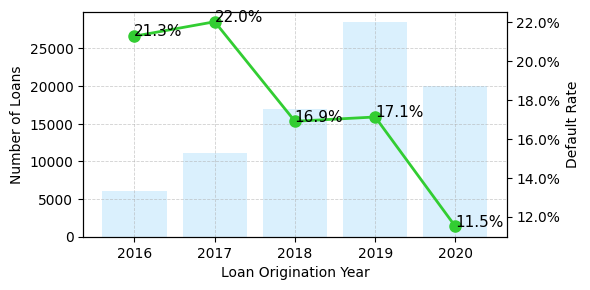

In [6]:
# PLOT TARGET VARIABLE

my_dr_plot(dr_summary, 2016, 2020)


### Pre-processing

#### split

In [7]:
# TRAIN/TEST SPLIT

X_trai, y_trai, X_test, y_test = my_time_split(full_dataset, 2016, 2018, 2019, 2020)

Train size: (34078, 39) (34078,)
Test size : (48446, 39) (48446,)
LoanYear
2018    16946
2017    11109
2016     6023
Name: count, dtype: int64
LoanYear
2019    28487
2020    19959
Name: count, dtype: int64
Train default rate: 0.19349727096660602
Test default rate : 0.1480617594847872


In [8]:
X_trai.info()

<class 'pandas.DataFrame'>
Index: 34078 entries, 1 to 162559
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Age                                     34078 non-null  int64  
 1   Amount                                  34078 non-null  float64
 2   AmountOfPreviousLoansBeforeLoan         34078 non-null  float64
 3   ApplicationSignedHour                   34078 non-null  int64  
 4   ApplicationSignedWeekday                34078 non-null  int64  
 5   AppliedAmount                           34078 non-null  float64
 6   CreditScoreEeMini                       34077 non-null  float64
 7   DebtToIncome                            34078 non-null  float64
 8   Education                               34076 non-null  float64
 9   EmploymentDurationCurrentEmployer       34077 non-null  str    
 10  EmploymentStatus                        9809 non-null   float64
 11  Exis

#### map categorical variables

In [9]:
# DEFINE PURE CATEGORICAL VARIABLES

categorical_variables = [
    "Education",         # 1,2,3,4,5
    "EmploymentStatus",  # 1,2,3,4,5,6
    "Gender",            # 0,1,2
    "HomeOwnershipType", # 0-10
    "LanguageCode",      # 1,2,3,4,5,6,9
    "MaritalStatus",     # 1-5
    "NewCreditCustomer", # 0,1
    "OccupationArea",    # 1-19
    "UseOfLoan",         # 0-8
    "VerificationType"   # 0-4
]

for col in categorical_variables:
    X_trai[col] = X_trai[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [10]:
# CONVERT STRING TO NUMERICAL: EmploymentDurationCurrentEmployer

var = "EmploymentDurationCurrentEmployer"
print(X_trai[var].value_counts(dropna=False))
# map on train
mapping = {
    "TrialPeriod": 0,
    "UpTo1Year": 1,
    "UpTo2Years": 2,
    "UpTo3Years": 3,
    "UpTo4Years": 4,
    "UpTo5Years": 5,
    "MoreThan5Years": 6,
    "Retiree": 7,
    "Other": np.nan
}
# apply
X_trai[var] = X_trai[var].map(mapping)
X_test[var] = X_test[var].map(mapping)
# check
print(X_trai[var].value_counts(dropna=False))

EmploymentDurationCurrentEmployer
MoreThan5Years    11913
UpTo5Years         8380
UpTo1Year          6742
UpTo2Years         2257
UpTo3Years         1891
UpTo4Years         1179
Retiree             733
Other               635
TrialPeriod         347
NaN                   1
Name: count, dtype: int64
EmploymentDurationCurrentEmployer
6.0    11913
5.0     8380
1.0     6742
2.0     2257
3.0     1891
4.0     1179
7.0      733
NaN      636
0.0      347
Name: count, dtype: int64


In [11]:
# CONVERT STRING TO NUMERICAL: WorkExperience 

var = "WorkExperience"
print(X_trai[var].value_counts(dropna=False))
# map on train
mapping = {
    "LessThan2Years": 0,
    "2To5Years": 2,
    "5To10Years": 5,
    "10To15Years": 10,
    "15To25Years": 15,
    "MoreThan25Years": 25
}
# apply
X_trai[var] = X_trai[var].map(mapping)
X_test[var] = X_test[var].map(mapping)
# check
print(X_trai[var].value_counts(dropna=False))

WorkExperience
NaN                24269
5To10Years          2279
15To25Years         1999
10To15Years         1827
2To5Years           1590
MoreThan25Years     1570
LessThan2Years       544
Name: count, dtype: int64
WorkExperience
NaN     24269
5.0      2279
15.0     1999
10.0     1827
2.0      1590
25.0     1570
0.0       544
Name: count, dtype: int64


In [12]:
# CONVERT BOOL TO NUMERICAL: NewCreditCustomer

var = "NewCreditCustomer"
print(X_trai[var].value_counts(dropna=False))
# apply
X_trai[var] = X_trai[var].astype("int64")
X_test[var] = X_test[var].astype("int64")
# check
print(X_trai[var].value_counts(dropna=False))

NewCreditCustomer
False    20825
True     13253
Name: count, dtype: int64
NewCreditCustomer
0    20825
1    13253
Name: count, dtype: int64


In [13]:
# align categories of test with categories of train
# if new categories appear -> NaN

cat_cols = X_trai.select_dtypes(include=["category"]).columns
for col in cat_cols:
    X_test[col] = pd.Categorical(
        X_test[col],
        categories=X_trai[col].cat.categories
    )

/var/folders/lw/lxw4ft892556gpxf0n3shwd40000gn/T/ipykernel_16410/1581236471.py:6: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[col] = pd.Categorical(


In [14]:
# check alignment train/test

print(set(X_trai.columns) == set(X_test.columns)) # should be true

dtype_check = pd.DataFrame({
    "trai_dtype": X_trai.dtypes,
    "test_dtype": X_test.dtypes
})
dtype_check[dtype_check["trai_dtype"] != dtype_check["test_dtype"]]

print((X_trai.columns == X_test.columns).all()) # should be true

True
True


#### missing values

In [15]:
# MISSING VALUES

# missing summary before
print(' ')
print('missing summary before:')
print(missing_summary(X_trai))

# separate nums/cats
cat_cols = X_trai.select_dtypes(include=["category"]).columns
num_cols = X_trai.select_dtypes(include=["int64", "float64"]).columns

# substitution values for numerical variables: median in training set
median_vals = X_trai[num_cols].median()
print('SUBSTITUTION VALUES FOR NUMS: ')
print(median_vals)

# substitution values for categorical variables: most common in training set
common_vals = X_trai[cat_cols].mode().iloc[0]
print('SUBSTITUTION VALUES FOR CATS: ')
print(common_vals)

# replace NaNs in numerical variables
X_trai[num_cols] = X_trai[num_cols].fillna(median_vals)
X_test[num_cols] = X_test[num_cols].fillna(median_vals)

# replace NaNs in categorical variables
X_trai[cat_cols] = X_trai[cat_cols].fillna(common_vals)
X_test[cat_cols] = X_test[cat_cols].fillna(common_vals)

# missing summary after
print(' ')
print('missing summary after:')
print(missing_summary(X_trai))

 
missing summary before:
                                        missing_count  missing_percent
WorkExperience                                  24269        71.216034
EmploymentStatus                                24269        71.216034
MaritalStatus                                   24269        71.216034
UseOfLoan                                       24269        71.216034
OccupationArea                                  24269        71.216034
PreviousEarlyRepaymentsBefoleLoan               11530        33.834145
PreviousRepaymentsBeforeLoan                     7471        21.923235
EmploymentDurationCurrentEmployer                 636         1.866307
Education                                           2         0.005869
HomeOwnershipType                                   2         0.005869
CreditScoreEeMini                                   1         0.002934
PreviousEarlyRepaymentsCountBeforeLoan              0         0.000000
IncomeTotal                                        

#### encode categorical variables

In [16]:
# get dummies, avoid dummy trap

X_trai = pd.get_dummies(X_trai, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align with train as reference

X_trai, X_test = X_trai.align(X_test, join="left", axis=1, fill_value=0)

# bools to int

X_trai[X_trai.select_dtypes(include="bool").columns] = X_trai[X_trai.select_dtypes(include="bool").columns].astype(int)
X_test[X_trai.select_dtypes(include="bool").columns] = X_test[X_trai.select_dtypes(include="bool").columns].astype(int)

In [17]:
print('SHAPES')
print(X_trai.shape)
print(X_test.shape)
print(y_trai.shape)
print(y_test.shape)

SHAPES
(34078, 84)
(48446, 84)
(34078,)
(48446,)


In [18]:
#X_trai.info()

<class 'pandas.DataFrame'>
Index: 34078 entries, 1 to 162559
Data columns (total 84 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Age                                     34078 non-null  int64  
 1   Amount                                  34078 non-null  float64
 2   AmountOfPreviousLoansBeforeLoan         34078 non-null  float64
 3   ApplicationSignedHour                   34078 non-null  int64  
 4   ApplicationSignedWeekday                34078 non-null  int64  
 5   AppliedAmount                           34078 non-null  float64
 6   CreditScoreEeMini                       34078 non-null  float64
 7   DebtToIncome                            34078 non-null  float64
 8   EmploymentDurationCurrentEmployer       34078 non-null  float64
 9   ExistingLiabilities                     34078 non-null  int64  
 10  FreeCash                                34078 non-null  float64
 11  Inco

#### scaling for LR

In [19]:
# SCALE VARIABLES FOR LR

scaler = StandardScaler()

X_trai_scaled = scaler.fit_transform(X_trai)
X_test_scaled = scaler.transform(X_test)

X_trai_scaled = pd.DataFrame(X_trai_scaled, columns=X_trai.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Modelling

#### models

In [20]:
# OPTIONAL (1/2): decrease number of variables using GB importance

# initial MODEL GB:
model_gb = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05)
model_gb.fit(X_trai, y_trai)

# feature importance
importance = pd.Series(model_gb.feature_importances_, index=X_trai.columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
selected_features = sorted.head(22).index.tolist()
# print
print(selected_features)

['NewCreditCustomer', 'AppliedAmount', 'LiabilitiesTotal', 'Education_5.0', 'Age', 'CreditScoreEeMini', 'PreviousRepaymentsBeforeLoan', 'HomeOwnershipType_8.0', 'LoanDuration', 'Education_2.0', 'LanguageCode_3', 'MonthlyPayment', 'ExistingLiabilities', 'WorkExperience', 'Amount', 'AmountOfPreviousLoansBeforeLoan', 'EmploymentDurationCurrentEmployer', 'FreeCash', 'ApplicationSignedHour', 'IncomeFromPrincipalEmployer', 'VerificationType_4.0', 'HomeOwnershipType_3.0']


In [21]:
# OPTIONAL (2/2): apply selected variables to train sets (replace)

# to original for GB
X_trai = X_trai[selected_features]
X_test = X_test[selected_features]

# to scaled for LG
X_trai_scaled = X_trai_scaled[selected_features]
X_test_scaled = X_test_scaled[selected_features]

# check sizes
print(X_trai.shape)
print(X_test.shape)
print(X_trai_scaled.shape)
print(X_test_scaled.shape)

(34078, 22)
(48446, 22)
(34078, 22)
(48446, 22)


In [22]:
# MODEL LR
model_lr = LogisticRegression(max_iter=10000, random_state=888)

# FIT
model_lr.fit(X_trai_scaled, y_trai)

# PREDICTIONS
y_pred_trai_lr = model_lr.predict_proba(X_trai_scaled)[:,1]
y_pred_test_lr = model_lr.predict_proba(X_test_scaled)[:,1]

# PERFORMANCE
auc = my_metrics(y_trai, y_pred_trai_lr)["AUC"]
accuracy_ratio_trai = 2 * auc - 1
print("TRAIN AUC :", auc)
print("TRAIN GINI:", accuracy_ratio_trai)
auc = my_metrics(y_test, y_pred_test_lr)["AUC"]
accuracy_ratio_test = 2 * auc - 1
print("TEST AUC :", auc)
print("TEST GINI:", accuracy_ratio_test)
# gini difference
print(" Δ GINI  :", accuracy_ratio_trai-accuracy_ratio_test)

----------------------------------------

----------------------------------------
AUC         : 0.6531
KS          : 0.2204
Observed DR : 19.35%
Mean PD     : 19.35%
Brier       : 0.1486
----------------------------------------
TRAIN AUC : 0.6531015238270044
TRAIN GINI: 0.30620304765400874
----------------------------------------

----------------------------------------
AUC         : 0.6518
KS          : 0.2228
Observed DR : 14.81%
Mean PD     : 20.32%
Brier       : 0.1247
----------------------------------------
TEST AUC : 0.6518380590813221
TEST GINI: 0.30367611816264417
 Δ GINI  : 0.0025269294913645712


In [ ]:
# MODEL GB:
model_gb = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05)

# FIT
model_gb.fit(X_trai, y_trai)

# PREDICTIONS
y_pred_trai_gb = model_gb.predict_proba(X_trai)[:,1]
y_pred_test_gb = model_gb.predict_proba(X_test)[:,1]

# PERFORMANCE
auc = my_metrics(y_trai, y_pred_trai_gb)["AUC"]
accuracy_ratio_trai = 2 * auc - 1
print("TRAIN AUC :", auc)
print("TRAIN GINI:", accuracy_ratio_trai)
auc = my_metrics(y_test, y_pred_test_gb)["AUC"]
accuracy_ratio_test = 2 * auc - 1
print("TEST AUC :", auc)
print("TEST GINI:", accuracy_ratio_test)
# gini difference
print(" Δ GINI  :", accuracy_ratio_trai-accuracy_ratio_test)

In [ ]:
# export train set to replicate model in pipeline
# print(X_trai_scaled.info())
# X_trai_scaled.to_pickle("X_train_old.pkl")

#### high importance variables

In [ ]:
# look for variable with largest absolute coefficient in the model

coef_table = pd.DataFrame({
    "feature": X_trai.columns,
    "coefficient": model_lr.coef_[0],
    "abs_coefficient": np.abs(model_lr.coef_[0])
})

coef_table = coef_table.sort_values("abs_coefficient", ascending=False)

print(coef_table)

In [ ]:
# plot variables vs dr

variable_vs_dr("NewCreditCustomer", X_trai, y_trai)
variable_vs_dr("CreditScoreEeMini", X_trai, y_trai)

In [ ]:
# create univariate models to check P>|z|

X_sm = sm.add_constant(X_trai['NewCreditCustomer'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

X_sm = sm.add_constant(X_trai['CreditScoreEeMini'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

X_sm = sm.add_constant(X_trai['ApplicationSignedHour'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

X_sm = sm.add_constant(X_trai['WorkExperience'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

#### calibration / threshold / default capture

In [ ]:
# chooce predictions from model LR to continue

y_pred_trai = y_pred_trai_lr
y_pred_test = y_pred_test_lr

In [ ]:
# re-calibrate (intercept-only) on test set
#(I want to align to actual portfolio DR)

y_pred_test_calibrated, delta = intercept_recalibration(y_test, y_pred_test)

print("Intercept shift (delta):", delta)
print("Old mean PD:", np.mean(y_pred_test))
print("New mean PD:", np.mean(y_pred_test_calibrated))
print("Observed DR:", np.mean(y_test))

In [ ]:
# export test set PDs to replicate model in pipeline

# y_pred_test_old = pd.DataFrame(y_pred_test_calibrated)
# print(y_pred_test_old.info())
# y_pred_test_old.to_pickle("y_pred_test_old.pkl")

In [ ]:
# CALIBRATION TABLE AND PLOT

my_calibration(y_test, y_pred_test_calibrated, dataset_name="", verbose=True)

In [ ]:
# PD THRESHOLD INVESTIGATION

thresholds = [0.05,0.07,0.10,0.15,0.20,0.30]
my_thresholds(y_test, y_pred_test_calibrated, thresholds)

In [ ]:
# PD THRESHOLD INVESTIGATION - PLOT FOR LinkedIn

thresholds = [0.05,0.07,0.10,0.15,0.20,0.30]
my_thresholds_li(y_test, y_pred_test_calibrated, thresholds)

In [ ]:
# DEFAULT CAPTURE CURVE

default_capture_curve(y_test, y_pred_test_calibrated)

## Business impact

#### portfolio share and default rate per PD bin: without/with PD threshold

In [ ]:
# impact

my_impact(y_test, y_pred_test_calibrated, 0.20)